# CS3 — Arctic sea-ice retreat, September 2012

Companion notebook for the *Computers & Geosciences* paper *An Open Python Framework for Reproducible Multi-Source Ocean Data Integration*. It loads the Zarr output produced by the offline fixture pipeline (`tests/fixtures/cs3_offline.yaml`) and reproduces the figures used in the Results section.

**Reproducibility contract.** Re-running this notebook from a fresh checkout regenerates the identical content hash printed in the final section. The pipeline is declarative (YAML) and the data sources are deterministic Beaufort/Chukchi-shaped fixtures that ship with the repository, so no external credentials are required.

**Scope note.** There is no live NSIDC connector in this codebase yet — the sea-ice field and its climatology are read through `LocalNetcdfSource`. `populate-fixtures` is the only fully automated reproduction path today (see `docs/datasets.md`).

## 1. Bootstrap — run the pipeline if its output is missing

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

# Resolve the repository root regardless of where the notebook is launched.
NB_DIR = Path.cwd()
if NB_DIR.name == 'notebooks':
    REPO_ROOT = NB_DIR.parent
else:
    REPO_ROOT = NB_DIR
os.chdir(REPO_ROOT)

PIPELINE = Path('tests/fixtures/cs3_offline.yaml')
OUTPUT   = Path('out/cs3_arctic_seaice_offline.zarr')
SIDECAR  = OUTPUT.with_suffix(OUTPUT.suffix + '.stac.json')

if not OUTPUT.exists():
    # Build synthetic fixtures (deterministic) and run the pipeline.
    from tests.fixtures.build_cs3_fixtures import build_all
    build_all(REPO_ROOT / 'tests' / 'fixtures' / 'cs3')
    import mosaic as ms
    ms.run(str(PIPELINE))

print(f'output: {OUTPUT} ({OUTPUT.exists()})')
print(f'sidecar: {SIDECAR} ({SIDECAR.exists()})')

output: out\cs3_arctic_seaice_offline.zarr (True)
sidecar: out\cs3_arctic_seaice_offline.zarr.stac.json (True)


## 2. Load the integrated dataset and its provenance sidecar

In [2]:
import xarray as xr

ds = xr.open_zarr(OUTPUT, consolidated=True)
with open(SIDECAR) as fh:
    stac = json.load(fh)

print(ds)

<xarray.Dataset> Size: 149kB
Dimensions:                            (time: 15, latitude: 11, longitude: 41)
Coordinates:
  * time                               (time) datetime64[ns] 120B 2012-09-01 ...
  * latitude                           (latitude) float32 44B 70.0 71.0 ... 80.0
  * longitude                          (longitude) float32 164B -170.0 ... -1...
Data variables:
    air_pressure_at_mean_sea_level     (time, latitude, longitude) float32 27kB ...
    air_temperature                    (time, latitude, longitude) float32 27kB ...
    melt_pond_proxy                    (time, latitude, longitude) bool 7kB ...
    sea_ice_area_fraction              (time, latitude, longitude) float32 27kB ...
    sea_ice_area_fraction_climatology  (time, latitude, longitude) float32 27kB ...
    sea_ice_area_fraction_qc           (time, latitude, longitude) int8 7kB ...
    sic_anomaly                        (time, latitude, longitude) float32 27kB ...
Attributes:
    Conventions:           C

In [3]:
props = stac['properties']
summary = {
    'pipeline_hash': props['mosaic:pipeline_hash'],
    'content_hash':  props['mosaic:content_hash'],
    'sources':       [s['source_id'] for s in props['mosaic:inputs']],
    'mapping_accuracy': props['mosaic:harmonization']['mapping_accuracy'],
    'derived_variables': props['mosaic:harmonization']['derived']['derived'],
}
summary

{'pipeline_hash': 'blake3:668a1bc01c4e6ce3d4ceb0dad572a745b82040623484dd46f7b1ed2cc655a10e',
 'content_hash': 'blake3:6b2e659305ca6545f9b1152a0d4d623109726b34f0402579697578fb89d2908a',
 'sources': ['nsidc_sic', 'era5_surface', 'sic_clim'],
 'mapping_accuracy': 1.0,
 'derived_variables': ['sic_anomaly', 'melt_pond_proxy']}

## 3. Sea-ice concentration evolution

Four-panel snapshot of `sea_ice_area_fraction` (harmonised from the NSIDC-like `sic` field) over the Beaufort/Chukchi sector, 1--15 September 2012, with the 15% and 50% SIC contours overlaid.

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})

n = ds.sizes['time']
panel_days = np.linspace(0, n - 1, 4, dtype=int)
panel_days

array([ 0,  4,  9, 14])

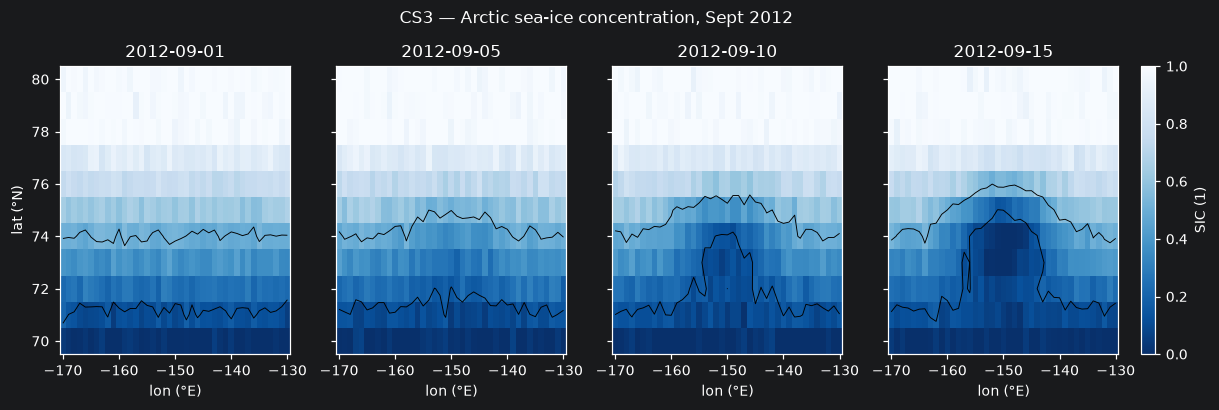

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
for ax, t in zip(axes, panel_days):
    sic = ds['sea_ice_area_fraction'].isel(time=t)
    pcm = ax.pcolormesh(
        sic.longitude, sic.latitude, sic.values,
        cmap='Blues_r', vmin=0.0, vmax=1.0, shading='auto',
    )
    ax.contour(sic.longitude, sic.latitude, sic.values, levels=[0.15, 0.5], colors='k', linewidths=0.6)
    ax.set_title(str(ds['time'].isel(time=t).values)[:10])
    ax.set_xlabel('lon (°E)')
axes[0].set_ylabel('lat (°N)')
fig.colorbar(pcm, ax=axes, fraction=0.025, pad=0.02, label='SIC (1)')
fig.suptitle('CS3 — Arctic sea-ice concentration, Sept 2012', y=1.03)
plt.show()

## 4. SIC anomaly against the long-term climatology

`sic_anomaly = sea_ice_area_fraction − sea_ice_area_fraction_climatology`, against a published September 1991-2020 climatology. The -0.3 contour highlights the strongest retreat.

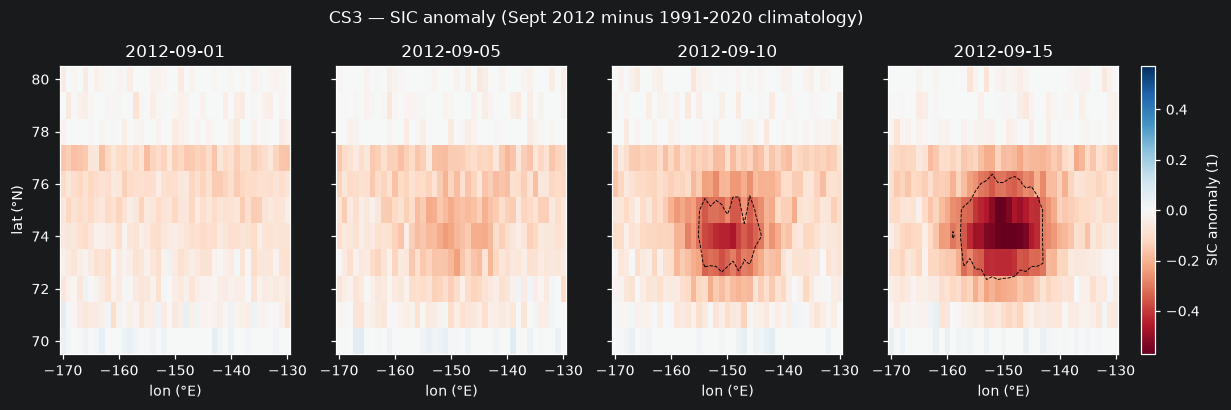

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
amax = float(np.abs(ds['sic_anomaly']).max())
for ax, t in zip(axes, panel_days):
    a = ds['sic_anomaly'].isel(time=t)
    pcm = ax.pcolormesh(
        a.longitude, a.latitude, a.values,
        cmap='RdBu', vmin=-amax, vmax=amax, shading='auto',
    )
    ax.contour(a.longitude, a.latitude, a.values, levels=[-0.3], colors='k', linewidths=0.6)
    ax.set_title(str(ds['time'].isel(time=t).values)[:10])
    ax.set_xlabel('lon (°E)')
axes[0].set_ylabel('lat (°N)')
fig.colorbar(pcm, ax=axes, fraction=0.025, pad=0.02, label='SIC anomaly (1)')
fig.suptitle('CS3 — SIC anomaly (Sept 2012 minus 1991-2020 climatology)', y=1.03)
plt.show()

## 5. Melt-pond proxy mask

`melt_pond_proxy = (sea_ice_area_fraction < 0.5) & (air_temperature > 273.15 K)` — a derived variable combining low SIC and above-freezing surface air from ERA5.

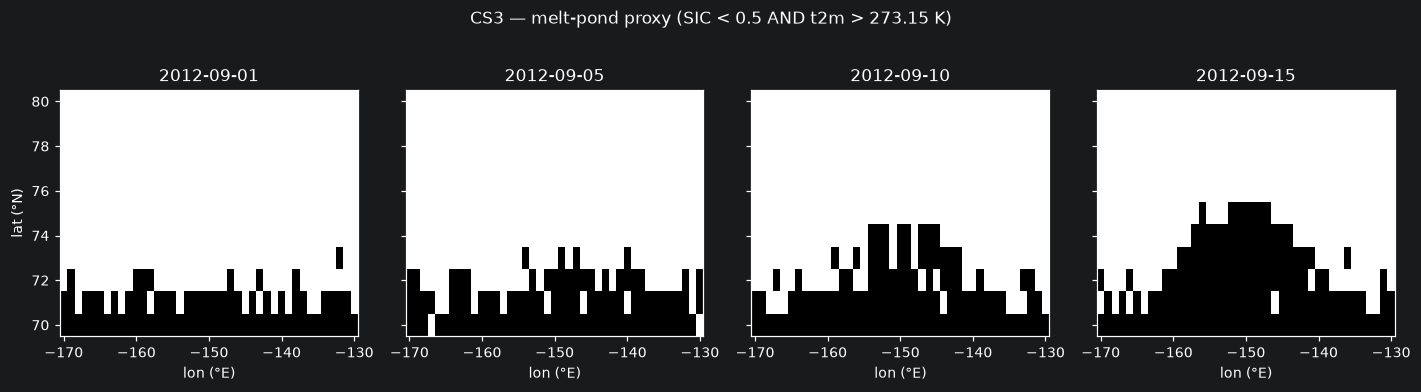

melt-pond proxy cells flagged (full window): 1609


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
for ax, t in zip(axes, panel_days):
    m = ds['melt_pond_proxy'].isel(time=t).astype('uint8')
    ax.pcolormesh(m.longitude, m.latitude, m.values, cmap='Greys', vmin=0, vmax=1, shading='auto')
    ax.set_title(str(ds['time'].isel(time=t).values)[:10])
    ax.set_xlabel('lon (°E)')
axes[0].set_ylabel('lat (°N)')
fig.suptitle('CS3 — melt-pond proxy (SIC < 0.5 AND t2m > 273.15 K)', y=1.03)
plt.tight_layout()
plt.show()

print(f"melt-pond proxy cells flagged (full window): "
      f"{int(ds['melt_pond_proxy'].astype('uint8').sum().values)}")

## 6. Sectorial ice area and melt-pond footprint over time

Total sea-ice area in the domain (in 10⁶ km², accounting for the latitude-dependent grid-cell area), against the daily count of `melt_pond_proxy` cells.

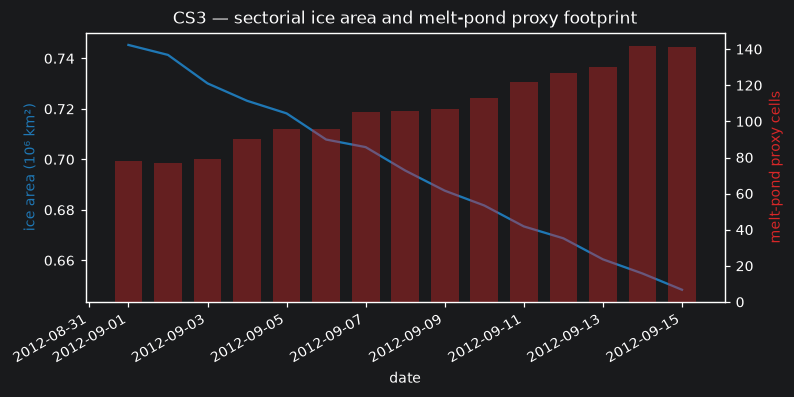

In [8]:
# area per cell ~ d_lat * d_lon * cos(lat) * 111^2 km^2
lat = ds['sea_ice_area_fraction'].latitude.values
dlon = float(np.diff(ds['sea_ice_area_fraction'].longitude.values).mean())
dlat = float(np.diff(lat).mean())
cell_area = (dlon * 111.0) * (dlat * 111.0) * np.cos(np.deg2rad(lat))[:, None]
sic_area_km2 = (
    ds['sea_ice_area_fraction'] * cell_area[None, :, :]
).sum(dim=('latitude', 'longitude')).values * 1e-6  # in million km²
flagged = ds['melt_pond_proxy'].astype('uint8').sum(dim=('latitude', 'longitude')).values

fig, ax1 = plt.subplots(figsize=(7.5, 3.6))
ax2 = ax1.twinx()
ax1.plot(ds['time'].values, sic_area_km2, color='tab:blue', label='ice area (10⁶ km²)')
ax2.bar(ds['time'].values, flagged, color='tab:red', alpha=0.4, width=0.7,
        label='melt-pond cells')
ax1.set_ylabel('ice area (10⁶ km²)', color='tab:blue')
ax2.set_ylabel('melt-pond proxy cells', color='tab:red')
ax1.set_xlabel('date')
fig.autofmt_xdate()
ax1.set_title('CS3 — sectorial ice area and melt-pond proxy footprint')
plt.show()

## 7. Provenance — content addressing of the result

Every MOSAIC run emits a STAC sidecar that pins the exact pipeline and the bit-exact output. The hashes below should match across machines and Python versions when the fixture-based pipeline is used.

In [9]:
for k in ('mosaic:pipeline_hash', 'mosaic:content_hash'):
    print(f'{k:<25} {props[k]}')

print()
print('inputs:')
for inp in props['mosaic:inputs']:
    print(f"  - {inp['source_id']:<10} {inp['plugin']:<14} {inp.get('uri', '')}")

print()
print('derived:')
for d in props['mosaic:harmonization']['derived']['derived']:
    print(f'  + {d}')

mosaic:pipeline_hash      blake3:668a1bc01c4e6ce3d4ceb0dad572a745b82040623484dd46f7b1ed2cc655a10e
mosaic:content_hash       blake3:6b2e659305ca6545f9b1152a0d4d623109726b34f0402579697578fb89d2908a

inputs:
  - nsidc_sic  local_netcdf   
  - era5_surface local_netcdf   
  - sic_clim   local_netcdf   

derived:
  + sic_anomaly
  + melt_pond_proxy


---
*Notebook generated by `notebooks/_build_cs3_notebook.py`. Do not edit by hand — regenerate from the script to keep the build auditable.*